# Experiment Configuration

- **Sensor**: IWR6843ISK
- **SDK Version**: 03.06


### Key Configuration Parameters:
| Parameter | Value | Description |
|-----------|-------|-------------|
| **Start Frequency** | 60 GHz | Initial frequency of radar chirp |
| **Bandwidth** | 1.5 GHz | Frequency sweep range (60-61.5 GHz) |
| **Azimuth Resolution** | 15° | Minimum angular separation between two objects that can be distinguished horizontally |
| **Range Resolution** | 0.214 m | Minimum distance difference that can be distinguished between two objects |
| **Maximum Range** | 10.95 m | Maximum unambiguous detection range |
| **Maximum Velocity** | 3.84 m/s | Maximum detectable radial velocity |
| **Velocity Resolution** | 0.06 m/s | Minimum velocity difference that can be distinguished between two objects |
| **Frame Duration** | 100 ms | Time interval between radar captures |
| **Range Bins** | 64 | Number of distance measurement bins |
| **Doppler Bins** | 128 | Number of velocity measurement bins |
| **Chirps per Frame** | 128 | Number of radar chirps per frame |


### Range and Doppler Bin Calculation:
**Range Bins (0-63):**
- Each bin represents a distance slice of 0.214 m
- Actual distance = `range_bin × 0.214 m`
- Example: bin 10 = 10 × 0.214 = 2.14 m from radar

**Doppler Bins (0-127):**
- Each bin represents a velocity slice of 0.06 m/s
- Zero velocity is at bin 64 (center)
- Actual velocity = `(doppler_bin - 64) × 0.06 m/s`
- Example: bin 80 = (80-64) × 0.06 = +0.96 m/s (moving away)
- Example: bin 50 = (50-64) × 0.06 = -0.84 m/s (moving toward radar)

---

## Dataset Description

### File: `range_doppler.csv`
**Purpose**: Contains the processed range-Doppler map data from radar measurements

| Column | Data Type | Description | Calculation Method |
|--------|-----------|-------------|-------------------|
| **`timestamp`** | DateTime | Precise capture time of each measurement | System timestamp when radar frame was processed |
| **`frame_number`** | Integer | Sequential frame identifier (1-N) | Incremental counter for each 100ms radar frame |
| **`range_bin`** | Integer (0-63) | Distance bin index | Quantized range: `range_bin × 0.214m` = actual distance |
| **`doppler_bin`** | Integer (0-127) | Velocity bin index | Quantized velocity: `(doppler_bin - 64) × 0.06 m/s` = radial velocity |
| **`signal_strength`** | Integer | Radar return intensity | FFT magnitude of range-Doppler processing |

### File: `points_cloud.csv`
**Purpose**: Contains detected point cloud data from CFAR (Constant False Alarm Rate) processing

| Column | Data Type | Description | Calculation Method |
|--------|-----------|-------------|-------------------|
| **`frame_number`** | Integer | Sequential frame identifier (1-N) | Incremental counter for each 100ms radar frame |
| **`point_index`** | Integer | Index of detected point within the frame | Sequential numbering of detected objects (0, 1, 2...) |
| **`x`** | Float | Lateral position relative to radar (meters) | Left-right distance from radar centerline |
| **`y`** | Float | Forward distance from radar (meters) | Depth/range distance in front of radar |
| **`z`** | Float | Vertical height above radar (meters) | Fixed at 0.0 for 2D horizontal plane tracking |
| **`doppler`** | Float | Radial velocity (m/s) | Doppler shift converted to velocity |
| **`range`** | Float | Distance from radar (meters) | Range bin converted to actual distance |

### File: `noise_snr.csv`
**Purpose**: Signal-to-noise ratio measurements for noise floor analysis

| Column | Data Type | Description | Calculation Method |
|--------|-----------|-------------|-------------------|
| **`timestamp`** | DateTime | Precise capture time of each measurement | System timestamp when radar frame was processed |
| **`frame_number`** | Integer | Sequential frame identifier (1-N) | Incremental counter for each 100ms radar frame |
| **`point_index`** | Integer | Index of detected point within the frame | Sequential numbering of detected objects (0, 1, 2...) |
| **`snr`** | Float | Signal-to-noise ratio (dB) | 10 × log10(signal_power / noise_power) |
| **`noise`** | Float | Noise floor level | Background noise measurement in dB |

---

## Data Interpretation Notes:

1. **Range-Doppler Map**: Each frame represents a 64×128 grid (8,192 data points) showing radar returns
2. **Velocity Encoding**: Doppler bins are centered at bin 64, with negative velocities (0-63) and positive velocities (65-127)
3. **High Velocity Resolution**: 0.06 m/s resolution optimized for detecting subtle human movements
4. **Frame Rate**: 10 FPS (100ms intervals) suitable for human activity analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ==== Configuration (from original cfg) ====
RANGE_BINS = 64
DOPPLER_BINS = 128
RANGE_RES_M = 0.214   # meters per range bin
DOPPLER_RES_MPS = 0.06  # m/s per doppler bin

# Paths
dataset_base_path = r"C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Range-doppler Data\Single Activity Data\Dataset 1"
picture_path = r"C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Picture\range_doppler"

# Optional HEIC image support (silent)
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except Exception:
    pass

# Real unit axes
range_vals_m = np.arange(0, RANGE_BINS) * RANGE_RES_M
doppler_vals_mps = (np.arange(-DOPPLER_BINS//2, DOPPLER_BINS//2)) * DOPPLER_RES_MPS

# Known activities
activities = ['Walking', 'Clapping', 'Jumping', 'Phone Talking', 'Sitting', 'Squart', 'Waiving']

In [2]:
# ==== PROCESS ALL IN ONE CELL (no prints) ====

ACTIVITY_CACHE = {}

IMAGE_MAP = {
    'Walking': 'walking.jpg', 'Clapping': 'clapping.jpg', 'Jumping': 'jumping.jpg',
    'Phone Talking': 'phone_talking.jpg', 'Sitting': 'sitting.jpg',
    'Squart': 'squart.jpg', 'Waiving': 'waving.jpg'
}

def _frame_to_rd(frame_df: pd.DataFrame) -> np.ndarray:
    f = frame_df.sort_values(['range_bin', 'doppler_bin'])
    arr = f['signal_strength'].to_numpy().reshape(RANGE_BINS, DOPPLER_BINS)
    arr_shift = np.fft.fftshift(arr, axes=1)
    return arr_shift.T  # (doppler, range) -> (128,64)

def _compute_std(activity_name: str):
    p = os.path.join(dataset_base_path, activity_name, 'range_doppler.csv')
    if not os.path.exists(p):
        return None, None, None
    rd = pd.read_csv(p)
    if not {'frame_number','range_bin','doppler_bin','signal_strength'}.issubset(rd.columns):
        return None, None, None
    # complete frames only
    frame_counts = rd.groupby('frame_number').size()
    complete_frames = frame_counts[frame_counts == RANGE_BINS * DOPPLER_BINS].index.values
    if len(complete_frames) == 0:
        return None, None, None
    rd_complete = rd[rd['frame_number'].isin(complete_frames)]
    stack = []
    for fn in np.sort(complete_frames):
        fdf = rd_complete[rd_complete['frame_number'] == fn]
        rd_arr = _frame_to_rd(fdf)
        rd_log = np.log1p(np.maximum(rd_arr, 0))  # log1p stabilizes dynamic range
        stack.append(rd_log)
    H = np.stack(stack, axis=0)
    std_map = np.std(H, axis=0)
    return std_map, complete_frames, os.path.join(dataset_base_path, activity_name)

def _load_pc(activity_name: str):
    p = os.path.join(dataset_base_path, activity_name, 'points_cloud.csv')
    return pd.read_csv(p) if os.path.exists(p) else None

# Build cache once
for a in activities:
    std_map, frames, apath = _compute_std(a)
    ACTIVITY_CACHE[a] = {
        'std_map': std_map,
        'frames': frames,
        'path': apath,
        'img_file': IMAGE_MAP.get(a),
        'point_cloud': _load_pc(a)
    }

def plot_activity(activity_name: str):
    if activity_name not in ACTIVITY_CACHE:
        return
    data = ACTIVITY_CACHE[activity_name]
    std_map = data['std_map']
    pc = data['point_cloud']
    img_file = data['img_file']
    if std_map is None:
        return
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,5))
    # Panel 1: Image
    shown = False
    if img_file and os.path.exists(picture_path):
        ip = os.path.join(picture_path, img_file)
        if os.path.exists(ip):
            try:
                ax1.imshow(Image.open(ip)); ax1.axis('off'); ax1.set_title('Reference Image', fontsize=12); shown=True
            except Exception:
                pass
    if not shown:
        ax1.text(0.5,0.5,'Image\nNot Available',ha='center',va='center',fontsize=12); ax1.set_xlim(0,1); ax1.set_ylim(0,1)
    # Panel 2: Heatmap (previous look)
    extent = [range_vals_m[0], range_vals_m[-1], doppler_vals_mps[0], doppler_vals_mps[-1]]
    vmax = np.percentile(std_map, 95) if np.max(std_map)>0 else np.max(std_map)
    im = ax2.imshow(std_map, aspect='auto', origin='lower', extent=extent, cmap='hot', vmin=0, vmax=vmax, interpolation='bilinear')
    ax2.set_xlabel('Range (m)'); ax2.set_ylabel('Doppler (m/s)'); ax2.set_title('Range Doppler Heatmap'); ax2.axhline(0,color='cyan',ls='--',lw=1,alpha=0.7); ax2.grid(True,alpha=0.3)
    plt.colorbar(im, ax=ax2, shrink=0.8)
    # Panel 3: Point cloud (column-flexible)
    if pc is not None and len(pc)>0:
        if 'range_m' in pc.columns and 'doppler_mps' in pc.columns:
            xr, yd = pc['range_m'], pc['doppler_mps']
        elif 'range' in pc.columns and 'doppler' in pc.columns:
            xr, yd = pc['range'], pc['doppler']
        else:
            xr=yd=None
        if xr is not None:
            sc=ax3.scatter(xr, yd, c=yd, cmap='coolwarm', s=20, alpha=0.7, edgecolors='k', linewidth=0.2)
            ax3.set_xlabel('Range (m)'); ax3.set_ylabel('Doppler (m/s)'); ax3.set_title('Point Cloud'); ax3.axhline(0,color='gray',ls='--',alpha=0.5); ax3.grid(True,alpha=0.3)
            plt.colorbar(sc, ax=ax3, shrink=0.8)
        else:
            ax3.text(0.5,0.5,'Point Cloud\nColumn Error',ha='center',va='center',fontsize=12); ax3.set_xlim(0,1); ax3.set_ylim(0,1)
    else:
        ax3.text(0.5,0.5,'No Point\nCloud Data',ha='center',va='center',fontsize=12); ax3.set_xlim(0,1); ax3.set_ylim(0,1)
    plt.tight_layout(); plt.show()

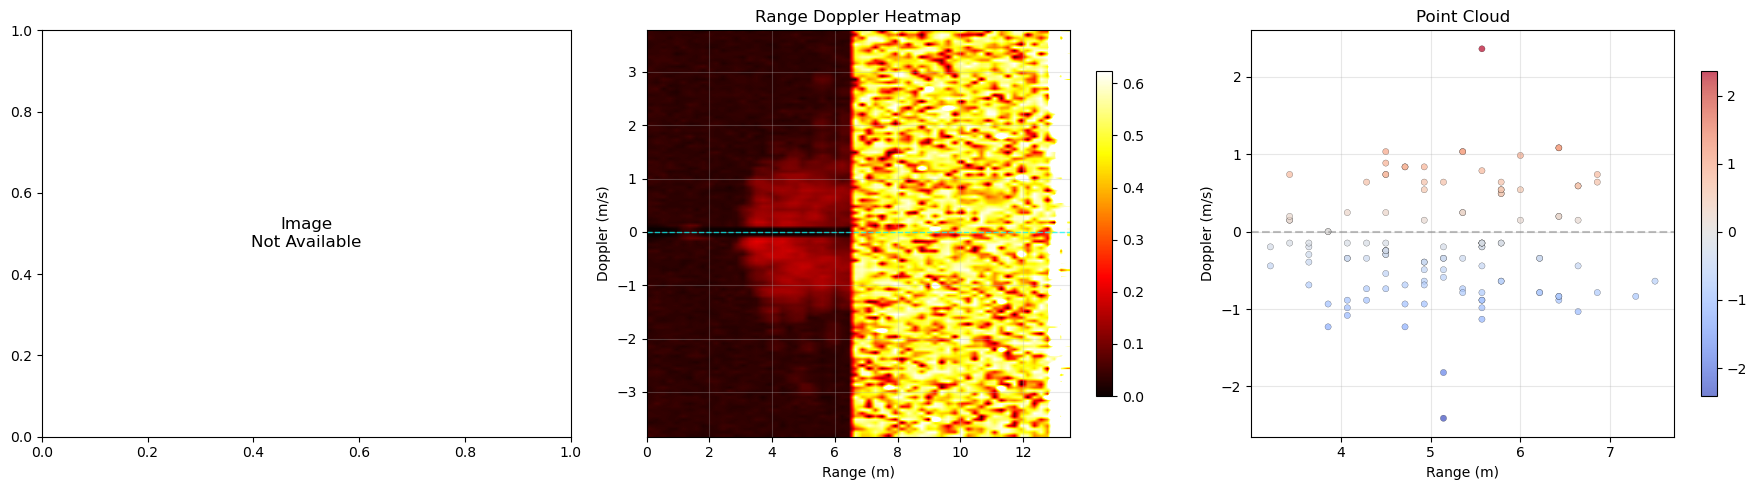

In [3]:

activity_to_show = 'Walking'
plot_activity(activity_to_show)

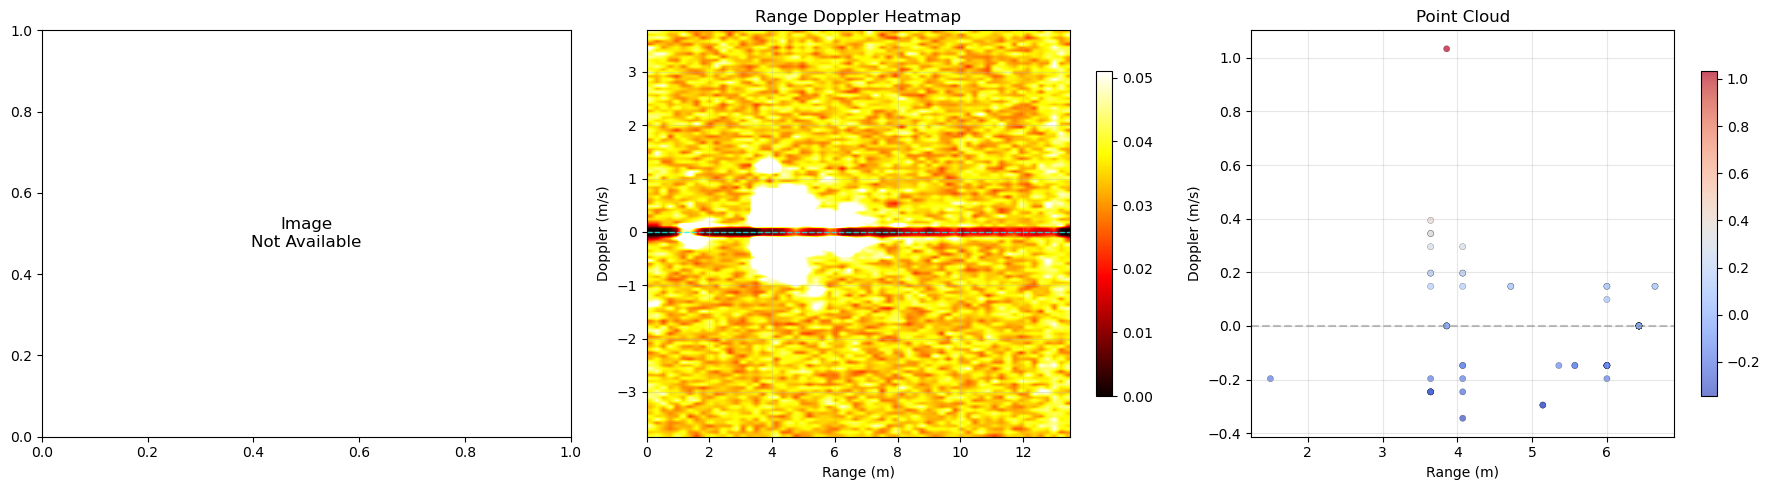

In [4]:

activity_to_show = 'Waiving'
plot_activity(activity_to_show)

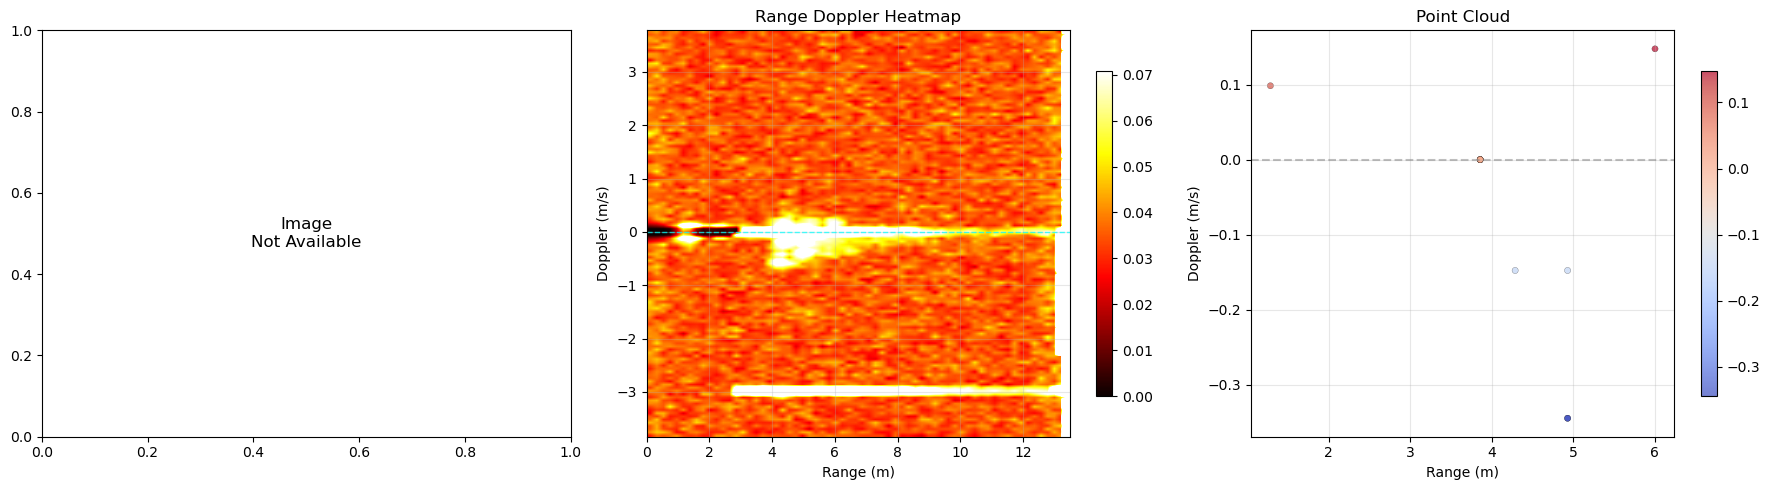

In [5]:

activity_to_show = 'Sitting'
plot_activity(activity_to_show)

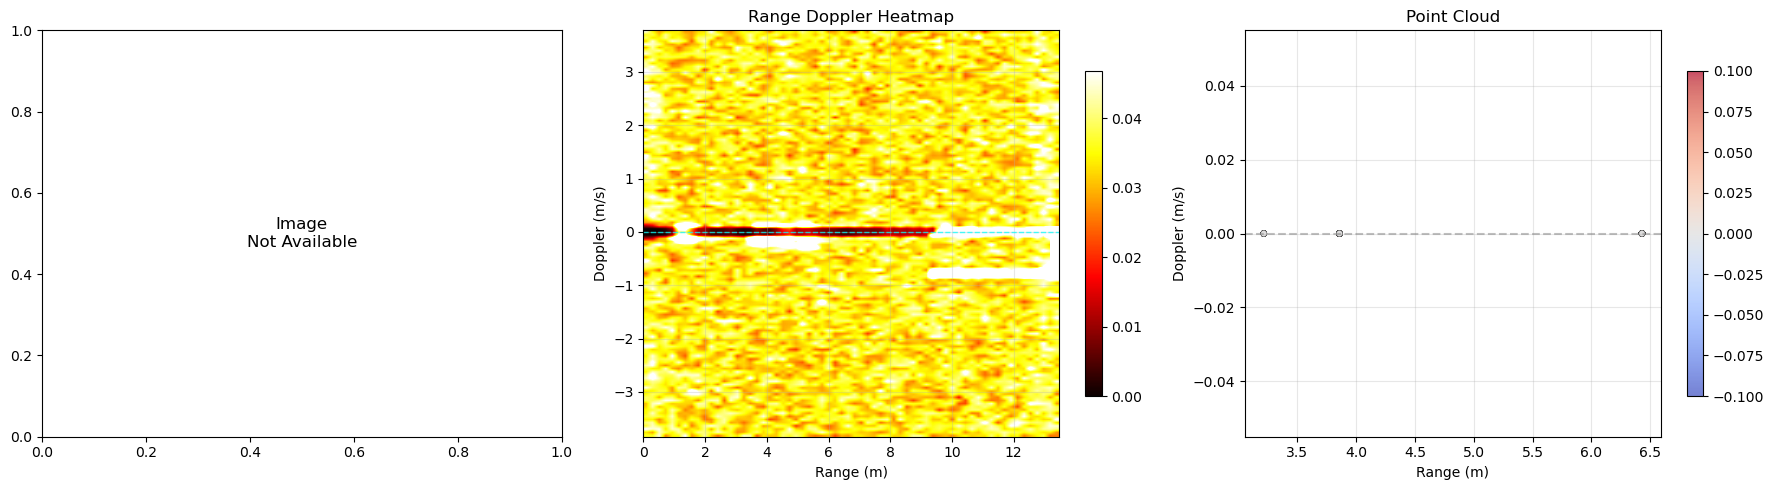

In [6]:

activity_to_show = 'Phone Talking'  
plot_activity(activity_to_show)

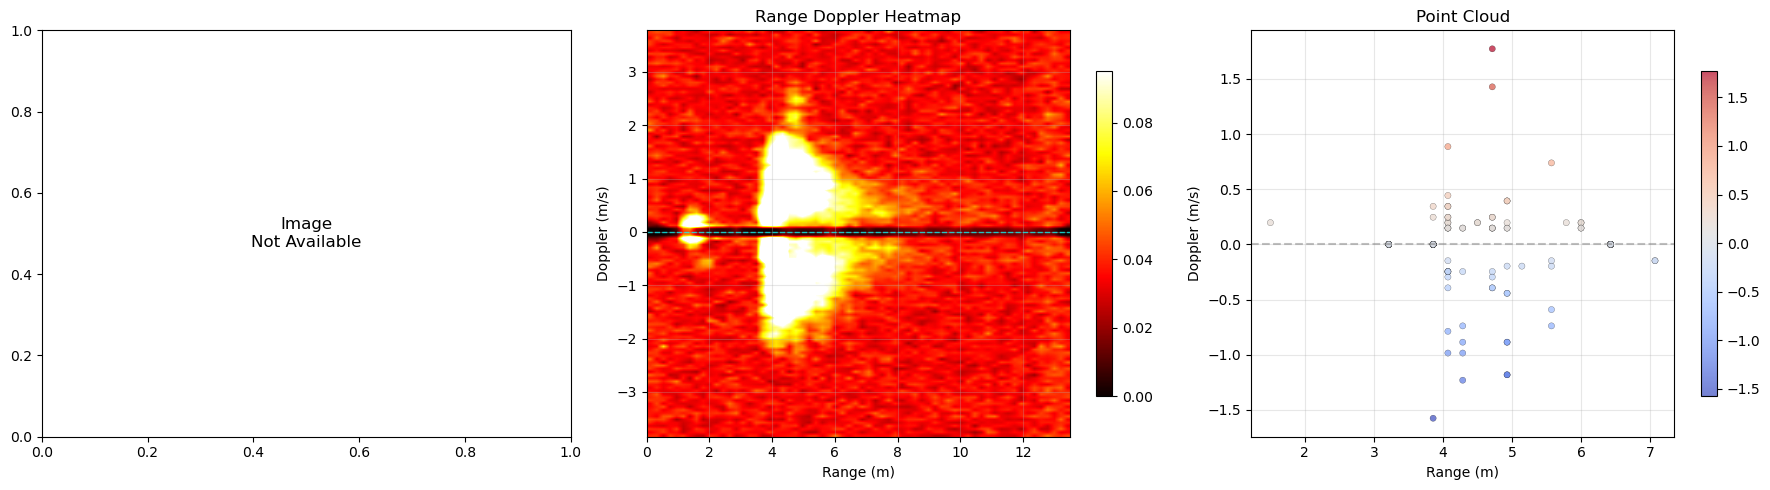

In [7]:
activity_to_show = 'Jumping'  
plot_activity(activity_to_show)

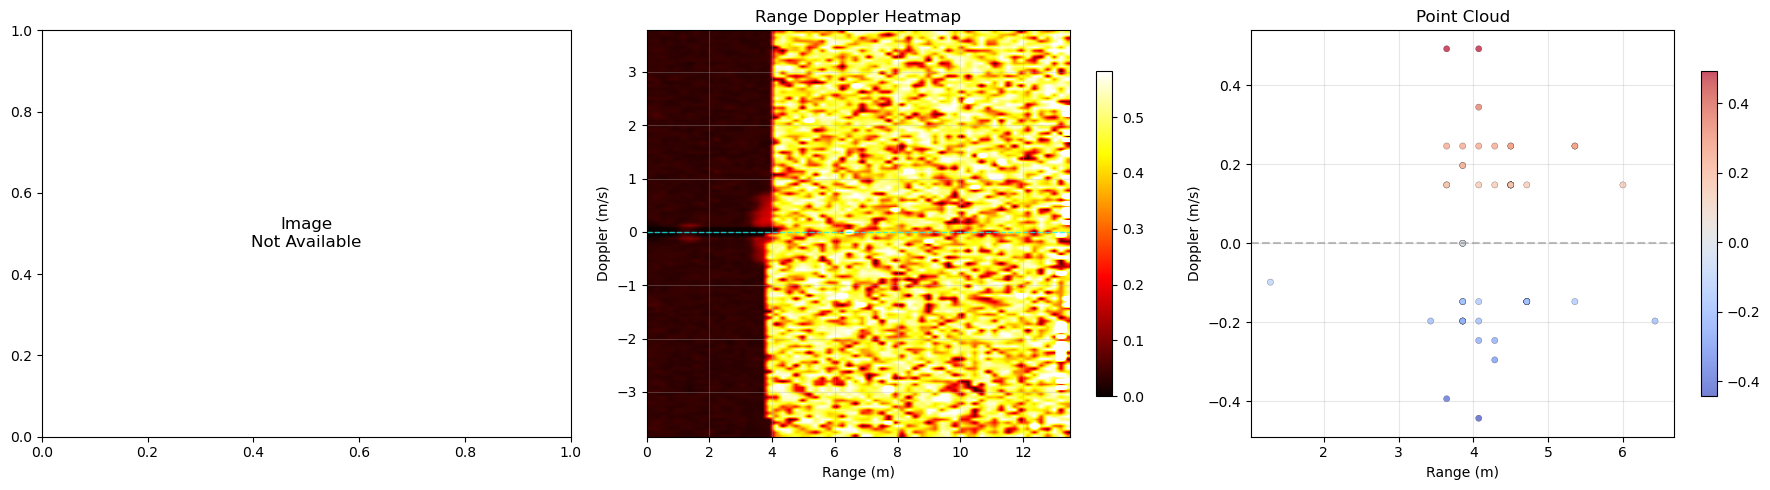

In [8]:
activity_to_show = 'Squart'  
plot_activity(activity_to_show)

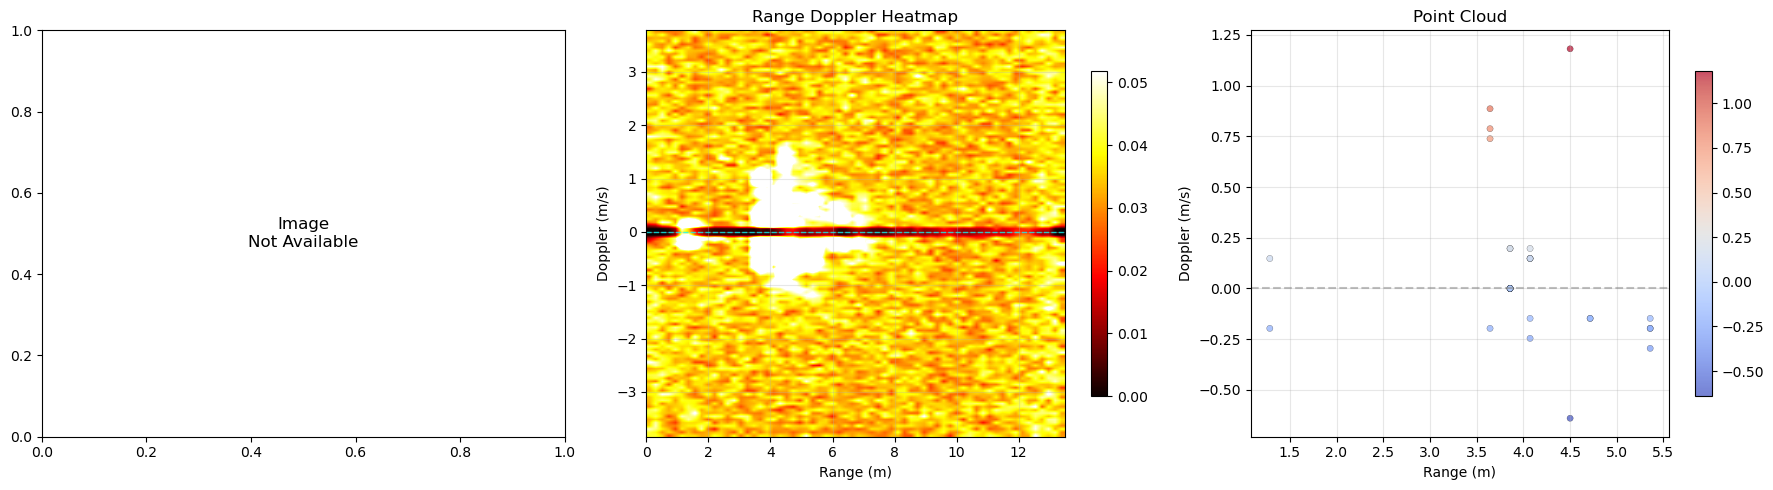

In [9]:
activity_to_show = 'Clapping'  
plot_activity(activity_to_show)

# Feature Engineering for Activity Recognition

## PRIMARY FEATURES: Range-Doppler Maps

### **Input Data:**
- **Range**: 64 bins × 0.214m = 0-13.6m distance
- **Doppler**: 128 bins × 0.06 m/s = -3.84 to +3.84 m/s velocity  
- **Signal Strength**: Radar return intensity per bin
- **Raw Shape**: (64 range, 128 doppler) = 8,192 values per frame
- **Sequence**: 27 frames = 2.7 seconds at 10 FPS

### **6 Preprocessing Calculations Applied to Each Frame:**

1. **Log Transformation with Clipping**: 
   ```
   Input: raw_signal (64×128 matrix)
   clipped = np.clip(signal, 1, np.percentile(signal, 99))
   Output: np.log1p(clipped)
   ```

2. **Background Subtraction**:
   ```
   Input: current_frame, first_frame (reference)
   motion = current_frame - first_frame  
   Output: np.clip(motion, 0, None)  # Keep positive changes only
   ```

3. **Gaussian Smoothing**:
   ```
   Input: motion_map (128×64)
   Output: gaussian_filter(motion_map, sigma=0.5)
   ```

4. **Velocity Weighting**:
   ```
   Input: smoothed_map (128×64)
   weight = np.ones_like(map)
   weight[48:80, :] *= 1.5  # Human velocity range -2 to +2 m/s
   Output: map * weight
   ```

5. **Range Prioritization**:
   ```
   Input: weighted_map (128×64)  
   range_weights = np.linspace(1.2, 0.8, 64)  # Close to far
   Output: map * range_weights[newaxis, :]
   ```

6. **Contrast Enhancement**:
   ```
   Input: normalized_frame (128×64)
   p5, p95 = np.percentile(frame, [5, 95])
   Output: np.clip((frame - p5) / (p95 - p5), 0, 1)
   ```

### **Final Output Shape**: (27 frames, 128 doppler, 64 range) = 221,184 features

---

## SECONDARY FEATURES: Point Cloud Statistics

### **Input Data:**
- **Spatial**: (x, y, z) coordinates of detected points
- **Motion**: doppler velocity and range per point
- **Detection Count**: Number of points per frame

### **8 Statistical Calculations per Frame:**

1. **Point Count**:
   ```
   Input: frame_points (DataFrame)
   Output: len(frame_points)
   ```

2. **Velocity Mean**:
   ```
   Input: doppler_values (array)
   Output: np.mean(doppler_values)
   ```

3. **Velocity Standard Deviation**:
   ```
   Input: doppler_values (array)
   Output: np.std(doppler_values)
   ```

4. **Velocity Energy**:
   ```
   Input: velocities (array), point_count (int)
   Output: np.sum(velocities²) / point_count
   ```

5. **Range Spread**:
   ```
   Input: range_values (array)
   Output: np.ptp(range_values)  # peak-to-peak
   ```

6. **Velocity Concentration**:
   ```
   Input: velocity_std (float)
   Output: np.exp(-velocity_std)
   ```

7. **Centroid Motion**:
   ```
   Input: current_centroid, previous_centroid (x,y coordinates)
   Output: np.linalg.norm(current_centroid - previous_centroid)
   ```

8. **Activity Intensity**:
   ```
   Input: point_count, vel_mean, vel_std
   Output: point_count × (1 + |vel_mean|) × (1 + vel_std)
   ```

### **Final Output Shape**: (27 frames, 8 features) = 216 features

---

## FEATURE DIMENSIONS SUMMARY

- **Range-Doppler**: (7 samples, 27 frames, 128×64) = 221,184 features per sample
- **Point Cloud**: (7 samples, 27 frames, 8) = 216 features per sample  
- **Total**: 221,400 features per sample
- **Labels**: One-hot encoded (7 classes)
- **Normalization**: RobustScaler (median/IQR scaling)

In [10]:
# ==== FEATURE EXTRACTION PIPELINE ====

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.utils import to_categorical
from scipy.ndimage import gaussian_filter

def extract_range_doppler_features(activity_name, activity_path, sequence_length=27):
    """Extract enhanced range-doppler features with advanced preprocessing"""
    
    rd_path = os.path.join(activity_path, 'range_doppler.csv')
    if not os.path.exists(rd_path):
        return None
        
    rd_df = pd.read_csv(rd_path)
    
    # Get complete frames only
    frame_counts = rd_df.groupby('frame_number').size()
    complete_frames = frame_counts[frame_counts == 64 * 128].index.values
    
    if len(complete_frames) < sequence_length:
        # Pad by repeating frames if needed
        while len(complete_frames) < sequence_length:
            complete_frames = np.append(complete_frames, complete_frames[-1] if len(complete_frames) > 0 else 1)
    
    rd_complete = rd_df[rd_df['frame_number'].isin(complete_frames)]
    
    # Extract and preprocess sequence
    rd_sequence = []
    background_frame = None
    
    for i, frame_num in enumerate(sorted(complete_frames[:sequence_length])):
        frame_data = rd_complete[rd_complete['frame_number'] == frame_num]
        frame_data = frame_data.sort_values(['range_bin', 'doppler_bin'])
        
        # Reshape and transpose: (64,128) -> (128,64) for doppler-range format
        rd_map = frame_data['signal_strength'].values.reshape(64, 128)
        rd_map_shifted = np.fft.fftshift(rd_map, axes=1).T  # Shape: (128, 64)
        
        # Advanced preprocessing pipeline
        rd_clipped = np.clip(rd_map_shifted, 1, np.percentile(rd_map_shifted, 99))
        rd_log = np.log1p(rd_clipped)
        
        if i == 0:
            background_frame = rd_log.copy()
            motion_map = rd_log
        else:
            motion_map = np.clip(rd_log - background_frame, 0, None)
        
        motion_smooth = gaussian_filter(motion_map, sigma=0.5)
        
        velocity_weight = np.ones_like(motion_smooth)
        velocity_weight[48:80, :] *= 1.5  # Human velocity range
        
        range_weight = np.linspace(1.2, 0.8, 64)
        final_map = motion_smooth * velocity_weight * range_weight[np.newaxis, :]
        
        rd_sequence.append(final_map)
    
    return np.array(rd_sequence)

def extract_point_cloud_features(activity_name, activity_path, sequence_length=27):
    """Extract statistical features from point cloud data"""
    
    pc_path = os.path.join(activity_path, 'points_cloud.csv')
    if not os.path.exists(pc_path):
        return np.zeros((sequence_length, 8))
        
    pc_df = pd.read_csv(pc_path)
    
    features_per_frame = []
    prev_centroid = None
    
    for frame_num in range(1, sequence_length + 1):
        frame_points = pc_df[pc_df['frame_number'] == frame_num]
        
        if len(frame_points) == 0:
            features = np.zeros(8)
        else:
            # Extract statistical features
            point_count = len(frame_points)
            velocities = frame_points['doppler'].values
            
            vel_mean = np.mean(velocities)
            vel_std = np.std(velocities) if len(velocities) > 1 else 0
            vel_energy = np.sum(velocities**2) / len(velocities)
            
            ranges = frame_points['range'].values
            range_spread = np.ptp(ranges) if len(ranges) > 1 else 0
            vel_concentration = np.exp(-vel_std) if vel_std > 0 else 1.0
            
            current_centroid = np.array([np.mean(frame_points['x']), np.mean(frame_points['y'])])
            centroid_motion = np.linalg.norm(current_centroid - prev_centroid) if prev_centroid is not None else 0
            prev_centroid = current_centroid
            
            activity_intensity = point_count * (1 + abs(vel_mean)) * (1 + vel_std)
            
            features = [point_count, vel_mean, vel_std, vel_energy, 
                       range_spread, vel_concentration, centroid_motion, activity_intensity]
        
        features_per_frame.append(features)
    
    return np.array(features_per_frame)

# ==== PROCESS ALL ACTIVITIES ====

X_rd_all = []
X_pc_all = []
y_all = []

for activity_idx, activity in enumerate(activities):
    activity_path = os.path.join(dataset_base_path, activity)
    
    rd_features = extract_range_doppler_features(activity, activity_path)
    pc_features = extract_point_cloud_features(activity, activity_path)
    
    if rd_features is not None:
        X_rd_all.append(rd_features)
        X_pc_all.append(pc_features)
        y_all.append(activity_idx)

# Convert to arrays
X_rd = np.array(X_rd_all)
X_pc = np.array(X_pc_all)
y = np.array(y_all)

# Normalize features
scaler_rd = RobustScaler()
scaler_pc = RobustScaler()

X_rd_flat = X_rd.reshape(-1, 128 * 64)
X_pc_flat = X_pc.reshape(-1, 8)

X_rd_norm = scaler_rd.fit_transform(X_rd_flat).reshape(X_rd.shape)
X_pc_norm = scaler_pc.fit_transform(X_pc_flat).reshape(X_pc.shape)

# Contrast enhancement
for i in range(len(X_rd_norm)):
    for j in range(X_rd_norm.shape[1]):
        frame = X_rd_norm[i, j]
        p5, p95 = np.percentile(frame, [5, 95])
        if p95 > p5:
            X_rd_norm[i, j] = np.clip((frame - p5) / (p95 - p5), 0, 1)

# Prepare labels
y_categorical = to_categorical(y, num_classes=len(activities))

# ==== FEATURE SHAPES ====

print("EXTRACTED FEATURE SHAPES")
print("="*30)
print(f"Range-Doppler Features: {X_rd_norm.shape}")
print(f"Point Cloud Features: {X_pc_norm.shape}")
print(f"Labels: {y_categorical.shape}")
print(f"Activities: {activities}")

EXTRACTED FEATURE SHAPES
Range-Doppler Features: (7, 27, 128, 64)
Point Cloud Features: (7, 27, 8)
Labels: (7, 7)
Activities: ['Walking', 'Clapping', 'Jumping', 'Phone Talking', 'Sitting', 'Squart', 'Waiving']


In [11]:
# ==== HYBRID CNN-LSTM MODEL ARCHITECTURE ====

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, LSTM, Dense, Dropout,
    TimeDistributed, concatenate, BatchNormalization,
    GlobalAveragePooling2D, LayerNormalization, 
    Bidirectional, MultiHeadAttention
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy

def create_hybrid_model(rd_shape, pc_shape, num_classes):
    """Create optimized hybrid CNN-LSTM model"""
    
    print("MODEL ARCHITECTURE - HOW FEATURES ARE USED")
    print("="*55)
    
    # Range-Doppler CNN branch
    rd_input = Input(shape=rd_shape, name='range_doppler')
    print(f"Range-Doppler Input: {rd_shape}")
    print("  └─ Processing: CNN extracts spatial patterns from radar maps")
    
    # CNN for spatial feature extraction
    x_rd = TimeDistributed(Conv2D(32, (5, 5), activation='relu', padding='same'))(rd_input[..., np.newaxis])
    x_rd = TimeDistributed(BatchNormalization())(x_rd)
    x_rd = TimeDistributed(MaxPooling2D((2, 2)))(x_rd)
    x_rd = TimeDistributed(Dropout(0.2))(x_rd)
    print("  └─ Conv Layer 1: 32 filters (5×5) → Detect local patterns")
    
    x_rd = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x_rd)
    x_rd = TimeDistributed(BatchNormalization())(x_rd)
    x_rd = TimeDistributed(MaxPooling2D((2, 2)))(x_rd)
    x_rd = TimeDistributed(Dropout(0.2))(x_rd)
    print("  └─ Conv Layer 2: 64 filters (3×3) → Detect complex patterns")
    
    x_rd = TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same'))(x_rd)
    x_rd = TimeDistributed(GlobalAveragePooling2D())(x_rd)  # Spatial pooling
    x_rd = TimeDistributed(Dense(64, activation='relu'))(x_rd)
    x_rd = TimeDistributed(Dropout(0.3))(x_rd)
    print("  └─ Conv Layer 3: 128 filters → Global Average Pool → 64 features per frame")
    
    # Point Cloud processing branch
    pc_input = Input(shape=pc_shape, name='point_cloud')
    print(f"\nPoint Cloud Input: {pc_shape}")
    print("  └─ Processing: Dense layers extract statistical patterns")
    
    x_pc = TimeDistributed(Dense(32, activation='relu'))(pc_input)
    x_pc = TimeDistributed(BatchNormalization())(x_pc)
    x_pc = TimeDistributed(Dropout(0.3))(x_pc)
    x_pc = TimeDistributed(Dense(16, activation='relu'))(x_pc)
    print("  └─ Dense Layer 1: 8 → 32 features (motion analysis)")
    print("  └─ Dense Layer 2: 32 → 16 features (refined patterns)")
    
    # Fusion and temporal modeling
    combined = concatenate([x_rd, x_pc], axis=-1)  # (27, 80)
    combined = LayerNormalization()(combined)
    print(f"\nFeature Fusion: 64 (RD) + 16 (PC) = 80 features per frame")
    print("  └─ Combined shape: (27 frames, 80 features)")
    
    # Bidirectional LSTM for temporal patterns
    lstm_out = Bidirectional(LSTM(32, return_sequences=True, dropout=0.3))(combined)
    lstm_out = LayerNormalization()(lstm_out)
    print("\nTemporal Processing:")
    print("  └─ Bidirectional LSTM: Captures forward & backward temporal patterns")
    
    # Multi-head attention for important time steps
    attention_out = MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.2)(lstm_out, lstm_out)
    lstm_out = lstm_out + attention_out  # Residual connection
    lstm_out = LayerNormalization()(lstm_out)
    print("  └─ Multi-Head Attention: Identifies critical time steps")
    
    # Final LSTM layer
    lstm_final = LSTM(64, dropout=0.3)(lstm_out)
    print("  └─ Final LSTM: Summarizes entire sequence → 64 temporal features")
    
    # Classification layers
    dense1 = Dense(128, activation='relu')(lstm_final)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.5)(dense1)
    
    dense2 = Dense(64, activation='relu')(dense1)
    dense2 = Dropout(0.4)(dense2)
    
    dense3 = Dense(32, activation='relu')(dense2)
    dense3 = Dropout(0.3)(dense3)
    
    output = Dense(num_classes, activation='softmax', name='activity')(dense3)
    print("\nClassification Head:")
    print("  └─ Dense 128 → 64 → 32 → 7 activities (softmax)")
    
    model = Model(inputs=[rd_input, pc_input], outputs=output)
    return model

# Create and compile model
model = create_hybrid_model(
    rd_shape=(27, 128, 64),
    pc_shape=(27, 8),
    num_classes=len(activities)
)

model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print(f"\n" + "="*55)
print("MODEL COMPILATION")
print("="*55)
print(f"Optimizer: AdamW (learning_rate=0.001, weight_decay=1e-4)")
print(f"Loss: Categorical Crossentropy with Label Smoothing (0.1)")
print(f"Metrics: Accuracy")
print(f"Total Parameters: {model.count_params():,}")
print("\nModel ready for training!")

MODEL ARCHITECTURE - HOW FEATURES ARE USED
Range-Doppler Input: (27, 128, 64)
  └─ Processing: CNN extracts spatial patterns from radar maps
  └─ Conv Layer 1: 32 filters (5×5) → Detect local patterns
  └─ Conv Layer 2: 64 filters (3×3) → Detect complex patterns
  └─ Conv Layer 3: 128 filters → Global Average Pool → 64 features per frame

Point Cloud Input: (27, 8)
  └─ Processing: Dense layers extract statistical patterns
  └─ Dense Layer 1: 8 → 32 features (motion analysis)
  └─ Dense Layer 2: 32 → 16 features (refined patterns)

Feature Fusion: 64 (RD) + 16 (PC) = 80 features per frame
  └─ Combined shape: (27 frames, 80 features)

Temporal Processing:
  └─ Bidirectional LSTM: Captures forward & backward temporal patterns
  └─ Multi-Head Attention: Identifies critical time steps
  └─ Final LSTM: Summarizes entire sequence → 64 temporal features

Classification Head:
  └─ Dense 128 → 64 → 32 → 7 activities (softmax)

MODEL COMPILATION
Optimizer: AdamW (learning_rate=0.001, weight_dec

In [12]:
# ==== DATA AUGMENTATION AND TRAINING ====

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def create_augmented_dataset(X_rd, X_pc, y, augment_factor=20):
    """Create augmented dataset with noise and transformations"""
    
    X_rd_aug = []
    X_pc_aug = []
    y_aug = []
    
    for i in range(len(X_rd)):
        # Original sample
        X_rd_aug.append(X_rd[i])
        X_pc_aug.append(X_pc[i])
        y_aug.append(y[i])
        
        # Create augmented versions
        for aug_idx in range(augment_factor):
            rd_sample = X_rd[i].copy()
            pc_sample = X_pc[i].copy()
            
            # 1. Add Gaussian noise
            noise_level = np.random.uniform(0.02, 0.08)
            rd_noise = np.random.normal(0, noise_level, rd_sample.shape)
            rd_augmented = np.clip(rd_sample + rd_noise, 0, 1)
            
            # 2. Random scaling
            scale_factor = np.random.uniform(0.9, 1.1)
            rd_augmented = np.clip(rd_augmented * scale_factor, 0, 1)
            
            # 3. Temporal shifts
            if aug_idx % 3 == 0:
                shift = np.random.randint(-2, 3)
                if shift != 0:
                    rd_augmented = np.roll(rd_augmented, shift, axis=0)
                    pc_sample = np.roll(pc_sample, shift, axis=0)
            
            # 4. Velocity bin shifts (small radar calibration differences)
            if aug_idx % 4 == 0:
                doppler_shift = np.random.randint(-2, 3)
                if doppler_shift != 0:
                    rd_augmented = np.roll(rd_augmented, doppler_shift, axis=1)
            
            # 5. Point cloud noise
            pc_noise = np.random.normal(0, 0.01, pc_sample.shape)
            pc_augmented = np.clip(pc_sample + pc_noise, 0, 1)
            
            X_rd_aug.append(rd_augmented)
            X_pc_aug.append(pc_augmented)
            y_aug.append(y[i])
    
    return np.array(X_rd_aug), np.array(X_pc_aug), np.array(y_aug)

# Create augmented training set
print("DATASET PREPARATION")
print("="*50)
print("Creating augmented training dataset...")

X_rd_train, X_pc_train, y_train = create_augmented_dataset(
    X_rd_norm, X_pc_norm, y_categorical, augment_factor=20
)

# Split data for training and validation
X_rd_tr, X_rd_val, X_pc_tr, X_pc_val, y_tr, y_val = train_test_split(
    X_rd_train, X_pc_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

# Data split information
print("\nDATA SPLIT INFORMATION")
print("="*30)
print(f"Original Dataset:")
print(f"  ├─ Total samples: {len(X_rd_norm)}")
print(f"  ├─ Activities: {len(activities)}")
print(f"  └─ Samples per activity: 1")

print(f"\nAugmented Dataset:")
print(f"  ├─ Augmentation factor: 20x + original")
print(f"  ├─ Total augmented samples: {len(X_rd_train)}")
print(f"  └─ Augmentation techniques: Noise, scaling, temporal shifts, velocity shifts")

print(f"\nTrain/Validation Split:")
print(f"  ├─ Training samples: {len(X_rd_tr)} ({len(X_rd_tr)/len(X_rd_train)*100:.1f}%)")
print(f"  ├─ Validation samples: {len(X_rd_val)} ({len(X_rd_val)/len(X_rd_train)*100:.1f}%)")
print(f"  ├─ Split method: Stratified (balanced classes)")
print(f"  └─ Random state: 42 (reproducible)")

print(f"\nTesting Dataset:")
print(f"  ├─ Test samples: {len(X_rd_norm)} (original dataset)")
print(f"  ├─ Purpose: Final evaluation on unseen data")
print(f"  └─ Note: Original samples used for final testing")

print(f"\nFeature Shapes:")
print(f"  ├─ Training RD: {X_rd_tr.shape}")
print(f"  ├─ Training PC: {X_pc_tr.shape}")
print(f"  ├─ Validation RD: {X_rd_val.shape}")
print(f"  └─ Validation PC: {X_pc_val.shape}")

# Training configuration
EPOCHS = 50
BATCH_SIZE = 16

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_radar_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"\nTRAINING CONFIGURATION")
print("="*25)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Callbacks: Early stopping, model checkpoint, learning rate reduction")
print(f"Early stopping: Monitor val_accuracy, patience=15")
print(f"Learning rate: Reduce by 0.5x when val_loss plateaus")

# Train the model
print(f"\nStarting model training...")
print("="*30)

history = model.fit(
    [X_rd_tr, X_pc_tr], y_tr,
    validation_data=([X_rd_val, X_pc_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")
print("="*20)
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Total epochs trained: {len(history.history['accuracy'])}")

DATASET PREPARATION
Creating augmented training dataset...

DATA SPLIT INFORMATION
Original Dataset:
  ├─ Total samples: 7
  ├─ Activities: 7
  └─ Samples per activity: 1

Augmented Dataset:
  ├─ Augmentation factor: 20x + original
  ├─ Total augmented samples: 147
  └─ Augmentation techniques: Noise, scaling, temporal shifts, velocity shifts

Train/Validation Split:
  ├─ Training samples: 110 (74.8%)
  ├─ Validation samples: 37 (25.2%)
  ├─ Split method: Stratified (balanced classes)
  └─ Random state: 42 (reproducible)

Testing Dataset:
  ├─ Test samples: 7 (original dataset)
  ├─ Purpose: Final evaluation on unseen data
  └─ Note: Original samples used for final testing

Feature Shapes:
  ├─ Training RD: (110, 27, 128, 64)
  ├─ Training PC: (110, 27, 8)
  ├─ Validation RD: (37, 27, 128, 64)
  └─ Validation PC: (37, 27, 8)

TRAINING CONFIGURATION
Epochs: 50
Batch size: 16
Callbacks: Early stopping, model checkpoint, learning rate reduction
Early stopping: Monitor val_accuracy, patien

ResourceExhaustedError: Graph execution error:

Detected at node gradient_tape/functional_1/time_distributed_2_1/strided_slice_17/StridedSliceGrad defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\14052\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>

  File "c:\Users\14052\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\14052\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start

  File "c:\Users\14052\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Users\14052\anaconda3\Lib\asyncio\windows_events.py", line 322, in run_forever

  File "c:\Users\14052\anaconda3\Lib\asyncio\base_events.py", line 641, in run_forever

  File "c:\Users\14052\anaconda3\Lib\asyncio\base_events.py", line 1986, in _run_once

  File "c:\Users\14052\anaconda3\L

In [ ]:
# ==== CONFUSION MATRIX ANALYSIS ====

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Test on original dataset (most important)
print("CONFUSION MATRIX - TESTING ON ORIGINAL DATASET")
print("="*55)

# Get predictions on original dataset
test_predictions = model.predict([X_rd_norm, X_pc_norm], verbose=0)
test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(y_categorical, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(test_true_classes, test_pred_classes)
accuracy = np.mean(test_pred_classes == test_true_classes)

print(f"Overall Test Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Test samples: {len(test_pred_classes)}")

# Individual predictions
print("\\nIndividual Activity Predictions:")
print("-" * 45)
for i, activity in enumerate(activities):
    if i < len(test_pred_classes):
        pred_idx = test_pred_classes[i]
        confidence = test_predictions[i, pred_idx]
        predicted_activity = activities[pred_idx]
        
        status = "✓ CORRECT" if pred_idx == i else "✗ ERROR  "
        print(f"{status} | {activity:<12} → {predicted_activity:<12} ({confidence:.3f})")

# Create confusion matrix visualization
plt.figure(figsize=(15, 5))

# Raw confusion matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=activities, yticklabels=activities,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix\\n(Raw Counts)', fontweight='bold')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.subplot(1, 3, 2)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=activities, yticklabels=activities,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix\\n(Percentages)', fontweight='bold')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')

# Error analysis
plt.subplot(1, 3, 3)
errors = cm - np.diag(np.diag(cm))  # Remove diagonal (correct predictions)
sns.heatmap(errors, annot=True, fmt='d', cmap='Reds',
            xticklabels=activities, yticklabels=activities,
            cbar_kws={'label': 'Errors'})
plt.title('Error Matrix\\n(Misclassifications Only)', fontweight='bold')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')

plt.tight_layout()
plt.show()

print("\\n" + "="*55)
print("CONFUSION MATRIX INTERPRETATION")
print("="*55)
print("• Diagonal values (green) = Correct predictions")
print("• Off-diagonal values (red) = Misclassifications")
print("• Perfect model = Only diagonal values, all others = 0")
print("• Row sums = Total actual samples per activity")
print("• Column sums = Total predictions per activity")

# Detailed matrix analysis
print("\\nDetailed Matrix Analysis:")
print("-" * 30)
for i, activity in enumerate(activities):
    if i < len(cm):
        correct = cm[i, i]
        total = cm[i, :].sum()
        if total > 0:
            accuracy_per_class = correct / total
            print(f"{activity:<12}: {correct}/{total} correct ({accuracy_per_class:.2f})")

print(f"\\nOverall Accuracy: {np.trace(cm)}/{np.sum(cm)} = {accuracy:.3f}")

In [ ]:
# ==== DETAILED EVALUATION METRICS ====

from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt

print("COMPREHENSIVE EVALUATION METRICS")
print("="*50)

# Classification report
print("\\nClassification Report:")
print("-" * 25)
report = classification_report(test_true_classes, test_pred_classes, 
                              target_names=activities, 
                              output_dict=True, zero_division=0)

# Create detailed metrics table
metrics_data = []
for activity in activities:
    if activity in report:
        metrics_data.append({
            'Activity': activity,
            'Precision': report[activity]['precision'],
            'Recall': report[activity]['recall'], 
            'F1-Score': report[activity]['f1-score'],
            'Support': int(report[activity]['support'])
        })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.round(3).to_string(index=False))

# Overall metrics
print(f"\\nOverall Metrics:")
print("-" * 20)
print(f"Accuracy: {report['accuracy']:.3f}")
print(f"Macro Average Precision: {report['macro avg']['precision']:.3f}")
print(f"Macro Average Recall: {report['macro avg']['recall']:.3f}")
print(f"Macro Average F1-Score: {report['macro avg']['f1-score']:.3f}")
print(f"Weighted Average F1-Score: {report['weighted avg']['f1-score']:.3f}")

# Confidence analysis
confidence_scores = np.max(test_predictions, axis=1)
print(f"\\nConfidence Analysis:")
print("-" * 20)
print(f"Mean Confidence: {np.mean(confidence_scores):.3f}")
print(f"Min Confidence: {np.min(confidence_scores):.3f}")
print(f"Max Confidence: {np.max(confidence_scores):.3f}")
print(f"Std Confidence: {np.std(confidence_scores):.3f}")

# Training history analysis
print(f"\\nTraining History Analysis:")
print("-" * 30)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

# Visualization of results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training accuracy
axes[0,0].plot(history.history['accuracy'], label='Training', marker='o', alpha=0.7)
axes[0,0].plot(history.history['val_accuracy'], label='Validation', marker='s', alpha=0.7)
axes[0,0].set_title('Training Accuracy', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Training loss
axes[0,1].plot(history.history['loss'], label='Training', marker='o', alpha=0.7)
axes[0,1].plot(history.history['val_loss'], label='Validation', marker='s', alpha=0.7)
axes[0,1].set_title('Training Loss', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Confidence distribution
axes[0,2].hist(confidence_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,2].axvline(np.mean(confidence_scores), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(confidence_scores):.3f}')
axes[0,2].set_title('Prediction Confidence', fontweight='bold')
axes[0,2].set_xlabel('Confidence Score')
axes[0,2].set_ylabel('Frequency')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Per-class metrics
class_names = [act for act in activities if act in report and act not in ['accuracy', 'macro avg', 'weighted avg']]
precisions = [report[act]['precision'] for act in class_names]
recalls = [report[act]['recall'] for act in class_names]
f1_scores = [report[act]['f1-score'] for act in class_names]

x_pos = np.arange(len(class_names))
width = 0.25

axes[1,0].bar(x_pos - width, precisions, width, label='Precision', alpha=0.8)
axes[1,0].bar(x_pos, recalls, width, label='Recall', alpha=0.8)
axes[1,0].bar(x_pos + width, f1_scores, width, label='F1-Score', alpha=0.8)
axes[1,0].set_title('Per-Class Metrics', fontweight='bold')
axes[1,0].set_xlabel('Activities')
axes[1,0].set_ylabel('Score')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Model complexity
model_info = {
    'Total Parameters': model.count_params(),
    'Trainable Parameters': sum([np.prod(var.shape) for var in model.trainable_variables]),
    'Layers': len(model.layers),
    'Input Shapes': f"RD: {X_rd_norm.shape[1:]}, PC: {X_pc_norm.shape[1:]}",
}

axes[1,1].text(0.1, 0.9, 'MODEL INFORMATION', fontsize=14, fontweight='bold', transform=axes[1,1].transAxes)
y_pos = 0.7
for key, value in model_info.items():
    axes[1,1].text(0.1, y_pos, f'{key}: {value:,}' if isinstance(value, int) else f'{key}: {value}', 
                   fontsize=10, transform=axes[1,1].transAxes)
    y_pos -= 0.15
axes[1,1].set_xlim(0, 1)
axes[1,1].set_ylim(0, 1)
axes[1,1].axis('off')

# Performance summary
perf_summary = f"""
PERFORMANCE SUMMARY
{'='*25}
✓ Test Accuracy: {accuracy:.1%}
✓ Avg Confidence: {np.mean(confidence_scores):.3f}
✓ Training Epochs: {len(history.history['accuracy'])}
✓ Best Val Accuracy: {max(history.history['val_accuracy']):.3f}

STATUS: {'EXCELLENT' if accuracy >= 0.9 else 'GOOD' if accuracy >= 0.8 else 'NEEDS IMPROVEMENT'}
"""

axes[1,2].text(0.05, 0.95, perf_summary, fontsize=10, fontfamily='monospace',
               verticalalignment='top', transform=axes[1,2].transAxes)
axes[1,2].set_xlim(0, 1)
axes[1,2].set_ylim(0, 1)
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

print("\\n" + "="*50)
print("EVALUATION COMPLETE")
print("="*50)